In [1]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import make_moons, make_circles

Projection of $u$ on $v$: $p_v u = \frac{<u,v>}{|v|^2}v$

<h4> Exercise1: 

<br>
    
a) Find the projections of the points $(3,2)$ and $(-2,0)$ onto the vector $v=[3,4]$
    
b) Find the projections of the points $(3,2,1)$ and $(-2,0,1)$ onto the vector $v=[3,4,-12]$

<h3> 
Principal component analysis (PCA)

Goal: reduce the number of feture but preserving information about the data (or at least a significant part)

How? Idea: Choose those directions where there is the greatest variability.
How? By projecting the data onto the eigenvectors of the covariance matrix corresponding to the largest eigenvalues.

Theorem: If the matrix is symmetric, then the eigenvectors corresponding to different eigenvalues are perpendicular.

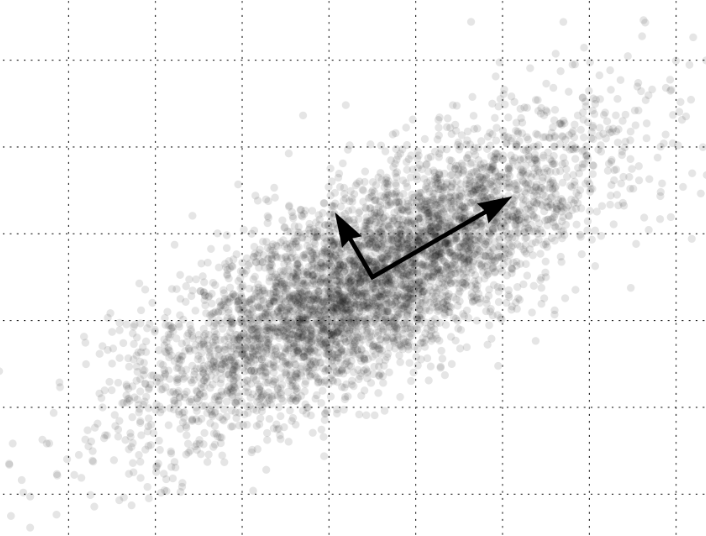

In [4]:
from IPython import display
display.Image("pca.png", width="500", height="300")

<h4> 
PCA as a method of visualizing high-dimensional data

In [2]:
from sklearn.datasets import load_digits

digits = load_digits()
print(digits.data.shape)

(1797, 64)


In [3]:
pca = PCA(2) #we may also specify the explained variance: n_components=0.95
digits2d = pca.fit_transform(digits.data) #reduce 64 features to 2
print(digits2d.shape)

(1797, 2)


In [4]:
digits.target

array([0, 1, 2, ..., 8, 9, 8])

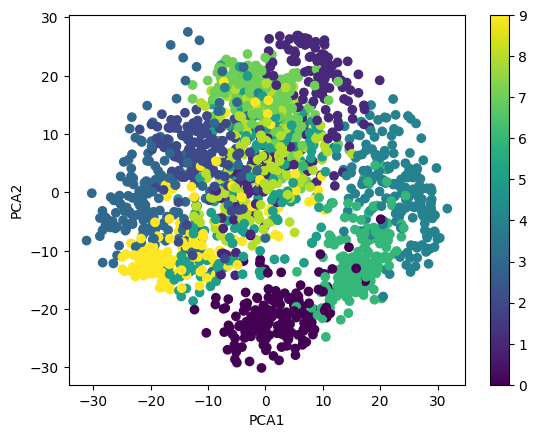

In [5]:
plt.scatter(digits2d[:,0], digits2d[:,1],
            c = digits.target)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.colorbar()
plt.show()

<h4> How much information is left?

In [6]:
df_wine = pd.read_csv('wine.data')
df_wine.columns = ['Class label', 'Alcohol', 'Malic acid', 'Ash', 
                   'Alcalinity of ash', 'Magnesium', 'Total phenols', 'Flavanolds', 
                   'Nonflavanoid phenols', 'Proanthocyanins', 'Color intensity', 
                   'Hue', 'OD280/OD315 of diluted wines', 'Proline']

X, y = df_wine.iloc[:, 1:].values, df_wine.iloc[:, 0].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=0)

stdsc = StandardScaler()
X_train_std = stdsc.fit_transform(X_train)
X_test_std = stdsc.transform(X_test)

df_wine.head()

,Class label,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanolds,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
1,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
2,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
3,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
4,1,14.20,1.76,2.45,15.2,112,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450


In [7]:
cov_mat = np.cov(X_train_std.T)
eigen_vals, eigen_vecs = np.linalg.eig(cov_mat) 
print('Eigenvalues \n%s'% eigen_vals)

Eigenvalues 
[4.80831621 2.60374779 1.37087288 0.89730848 0.89417853 0.61503055
 0.52428622 0.09986474 0.36400572 0.1628064  0.30351535 0.23651936
 0.22610515]


In [8]:
tot = sum(eigen_vals)
var_exp = [(i/tot) for i in sorted(eigen_vals, reverse=True)]
var_exp_cum = np.cumsum(var_exp) # stepping-sum

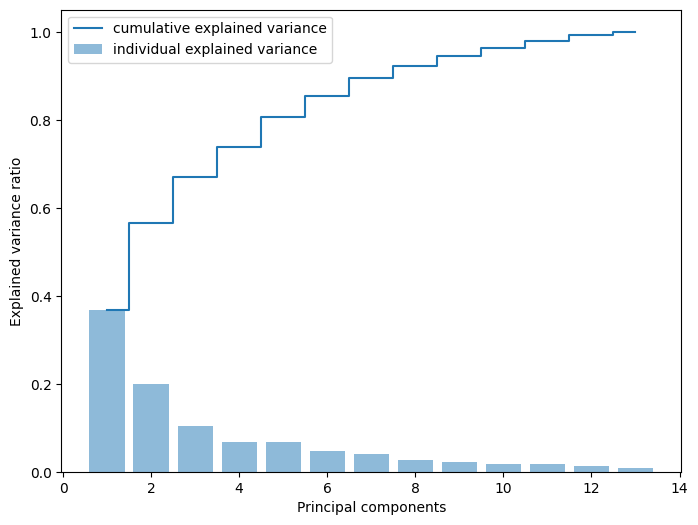

In [9]:
plt.figure(figsize=(8,6))
plt.bar( range(1, 14), var_exp,     alpha=0.5,   align='center', label='individual explained variance')
plt.step(range(1, 14), var_exp_cum, where='mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc='best')
plt.show()

In [10]:
eigen_pairs = [(np.abs(eigen_vals[i]), eigen_vecs[:, i]) for i in range(len(eigen_vals))]
eigen_pairs[0:2]

[(4.808316207963477,
  array([ 0.11764947, -0.27125589, -0.00287842, -0.2187704 ,  0.11381354,
          0.3883771 ,  0.41798859, -0.30781073,  0.31891453, -0.09956432,
          0.31677259,  0.38268756,  0.27026597])),
 (2.6037477936979103,
  array([-0.48449198, -0.22537291, -0.37849214, -0.00424088, -0.29832137,
         -0.08395627, -0.03573104, -0.05530974, -0.03466028, -0.51335364,
          0.21549584,  0.13494201, -0.37608379]))]

In [11]:
w = np.hstack((eigen_pairs[0][1][:, np.newaxis], 
               eigen_pairs[1][1][:, np.newaxis]))

X_train_pca = X_train_std.dot(w)

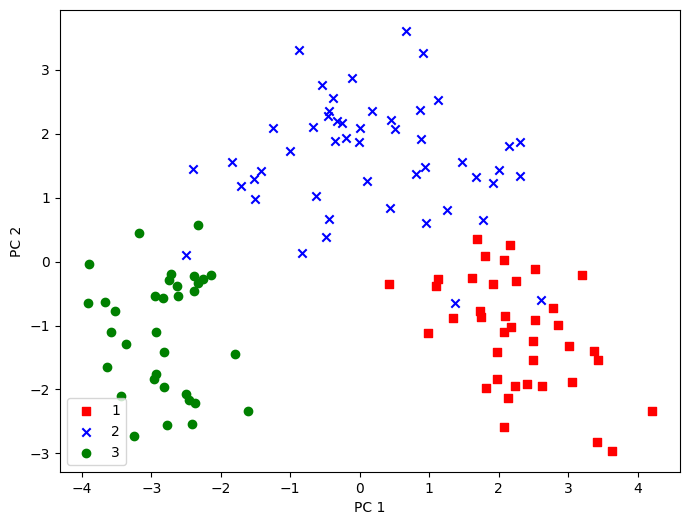

In [12]:
colors  = ['r', 'b', 'g']
markers = ['s', 'x', 'o']
plt.figure(figsize=(8,6))
for l, c, m in zip(np.unique(y_train), colors, markers):
    plt.scatter(X_train_pca[y_train==l, 0], 
                X_train_pca[y_train==l, 1],
                c=c, label=l, marker=m)
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.legend(loc='lower left')
plt.show()

Of course it's all implemented :)


In [13]:
pca = PCA(n_components=None)
X_train_pca = pca.fit_transform(X_train_std)
pca.explained_variance_ratio_

array([0.3668634 , 0.19865993, 0.10459443, 0.06846256, 0.06822375,
       0.04692541, 0.04000183, 0.02777279, 0.02315752, 0.01804588,
       0.0172513 , 0.01242175, 0.00761945])

In [14]:
print(pca.components_[:3]) #three frist components

[[ 0.11764947 -0.27125589 -0.00287842 -0.2187704   0.11381354  0.3883771
   0.41798859 -0.30781073  0.31891453 -0.09956432  0.31677259  0.38268756
   0.27026597]
 [ 0.48449198  0.22537291  0.37849214  0.00424088  0.29832137  0.08395627
   0.03573104  0.05530974  0.03466028  0.51335364 -0.21549584 -0.13494201
   0.37608379]
 [-0.22676228  0.0915252   0.56611151  0.66946119  0.14770786  0.15502807
   0.14704292  0.07138073  0.04901835 -0.18399456  0.08151526  0.17418972
  -0.16040494]]


We usually take the number of components so that the total explained variance is at least 80-90\%

<h4> Exercise2: Consider the iris dataset. Standardize it, and then apply the PCA algorithm.
How many components are sufficient to describe the data?
Which of the original features has the strongest impact on the first principal component?
Build an SVM classifier using both the original features and the reduced set of features (from PCA).
Comment on your results.

In [2]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

<h3> Linear Discriminant Analysis (LDA) 

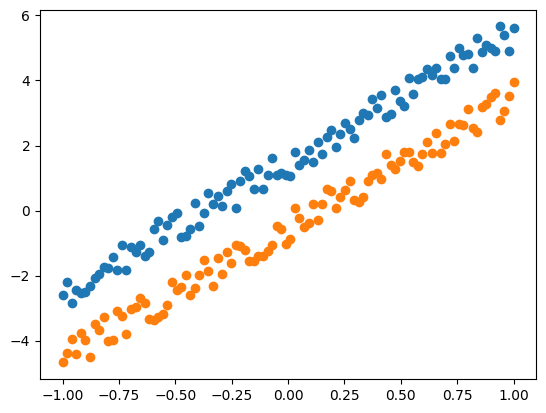

In [15]:
rng = np.random.RandomState(1)
x = np.linspace(-1, 1, 100)
y1 = 4*x+1+rng.random(100)
y2 = 4*x-1+rng.random(100)

X = np.array((np.append(x, x),np.append(y1, y2))).T
label = np.array([0]*100+[1]*100)
plt.scatter(x,y1)
plt.scatter(x,y2)
plt.show()

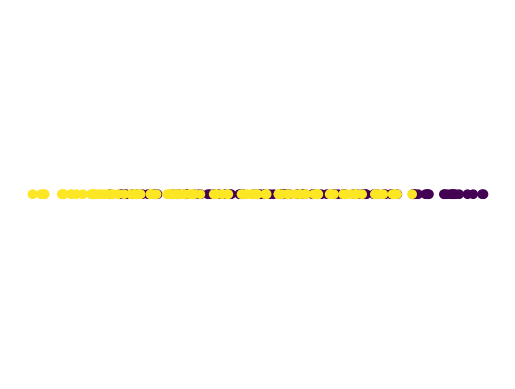

In [16]:
#PCA

pca = PCA(1)
X1dpca = pca.fit_transform(X) 

z = np.ones(np.shape(X1dpca))
plt.scatter(X1dpca,z, c = label)
plt.axis("off")
plt.show()

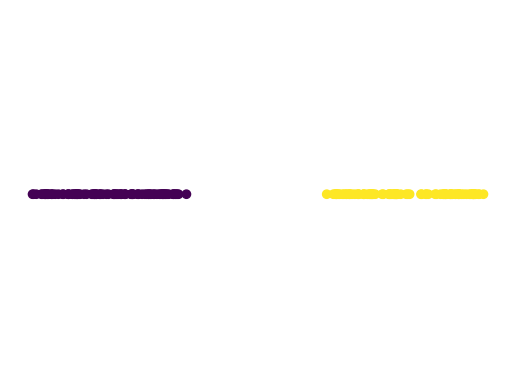

In [17]:
#LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
lda = LinearDiscriminantAnalysis(n_components=1)
X1dlda = lda.fit_transform(X, label)

z = np.ones(np.shape(X1dlda))
plt.scatter(X1dlda,z, c = label)
plt.axis("off")
plt.show()

<h4> Exercise3: Consider the codon log frequencies in selected plants, viruses, and bacteria. 
    
- Standardize the data. Then, perform PCA with 2 components. Visualize the reduced data, coloring the observations according to their kingdom. Next, apply LDA with 2 components and visualize the reduced data, again coloring observations by kingdom. Provide comments on the differences between the PCA and LDA visualizations.

- Finally, perform k-means clustering with 3 clusters on the LDA-reduced data. Evaluate how well the predicted clusters correspond to the actual organism categories (kingdoms).

In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("codon_usage.csv")
df = df[df['Kingdom'].isin(['pln', 'vrl','bct'])]
print(df.head())
print(df.describe())
df['UGA;'] = df['UGA;'].str.replace(';', '')
y = df["Kingdom"]
X = df.drop(columns=["Kingdom","DNAtype", "SpeciesID", "Ncodons", "SpeciesName"]).apply(pd.to_numeric, errors='coerce').apply(lambda x: np.log(x + 0.001))

  Kingdom  DNAtype  SpeciesID  Ncodons  \
0     vrl        0     100217     1995   
1     vrl        0     100220     1474   
2     vrl        0     100755     4862   
3     vrl        0     100880     1915   
4     vrl        0     100887    22831   

                               SpeciesName      UUU      UUC      UUA  \
0  Epizootic haematopoietic necrosis virus  0.01654  0.01203  0.00050   
1                         Bohle iridovirus  0.02714  0.01357  0.00068   
2             Sweet potato leaf curl virus  0.01974  0.02180  0.01357   
3             Northern cereal mosaic virus  0.01775  0.02245  0.01619   
4           Soil-borne cereal mosaic virus  0.02816  0.01371  0.00767   

       UUG      CUU  ...      CGG      AGA      AGG      GAU      GAC  \
0  0.00351  0.01203  ...  0.00451  0.01303  0.03559  0.01003  0.04612   
1  0.00678  0.00407  ...  0.00136  0.01696  0.03596  0.01221  0.04545   
2  0.01543  0.00782  ...  0.00596  0.01974  0.02489  0.03126  0.02036   
3  0.00992  0.01

<h3> Independent Component Analysis (ICA)

- We assume that we have a linear mixture of independent signals (e.g. voices of several people speaking simultaneously; the so-called cocktail party problem). The goal: to find these (original) signals


<center> $x=As$

$A$ - mixing matrix (unknown), $s$ - original signals (uknonwn), $x$ - observed (known)

ICA application:
- processing of medical signals (fMRI, ECG, EEG)
- Brain Computer Interface
- time series analysis (e.g. in finance)

and many others

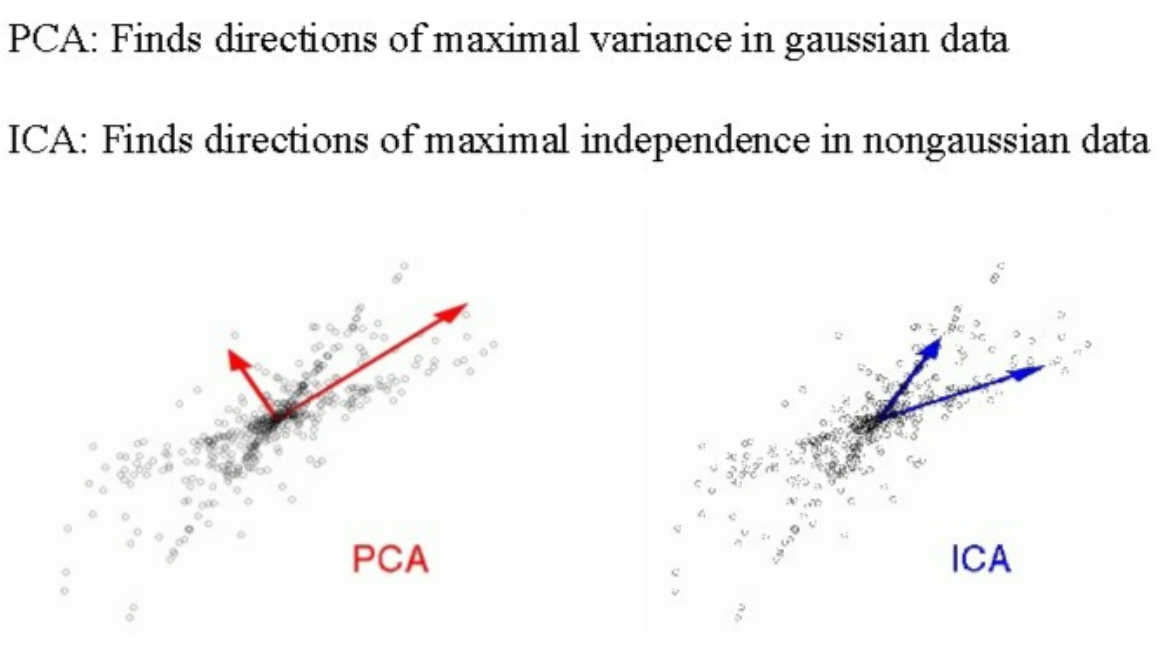

In [41]:
display.Image("icapca.png", width="800", height="500")

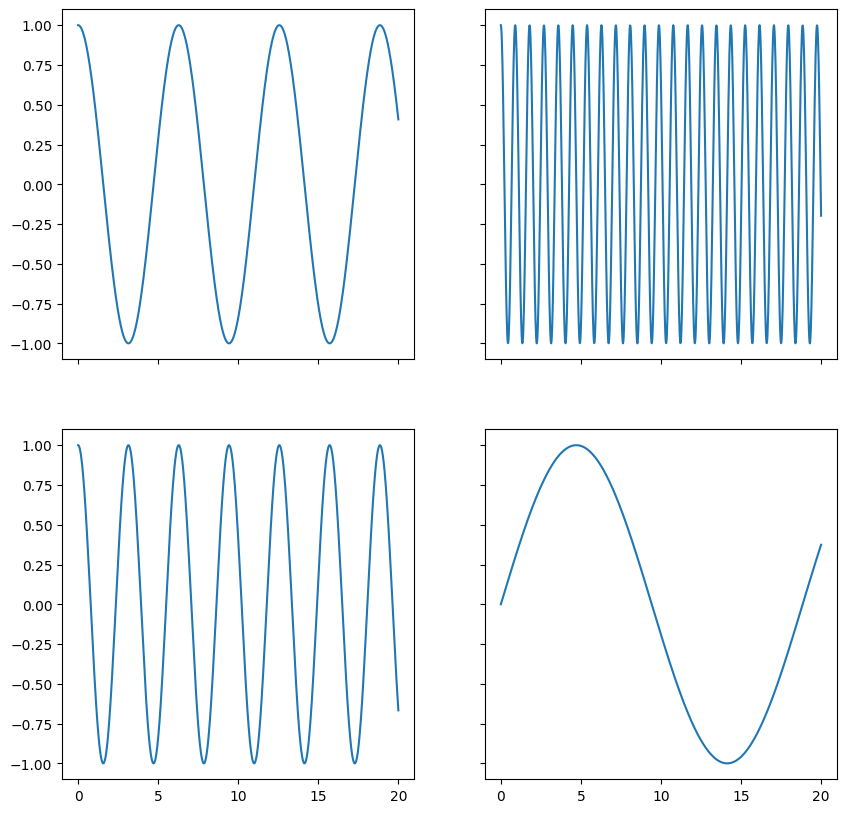

In [38]:
n = 1000
x = np.linspace(0, 20, n)
y1 = np.cos(x)
y2 = np.cos(2*x)
y3 = np.sin(x/3)
y4 = np.cos(7*x)

fig, ax = plt.subplots(2, 2, sharex = "col", sharey = "row", figsize = (10,10))

ax[0,0].plot(x,y1)
ax[1,0].plot(x,y2)
ax[1,1].plot(x,y3)
ax[0,1].plot(x,y4)

plt.show()

[[0.98458972 0.62772997 0.40088961 0.06419825]
 [0.48447016 0.52842954 0.16553836 0.51795374]
 [0.87593277 0.28967726 0.38217667 0.93182534]
 [0.93763763 0.53060335 0.94422747 0.48113113]]


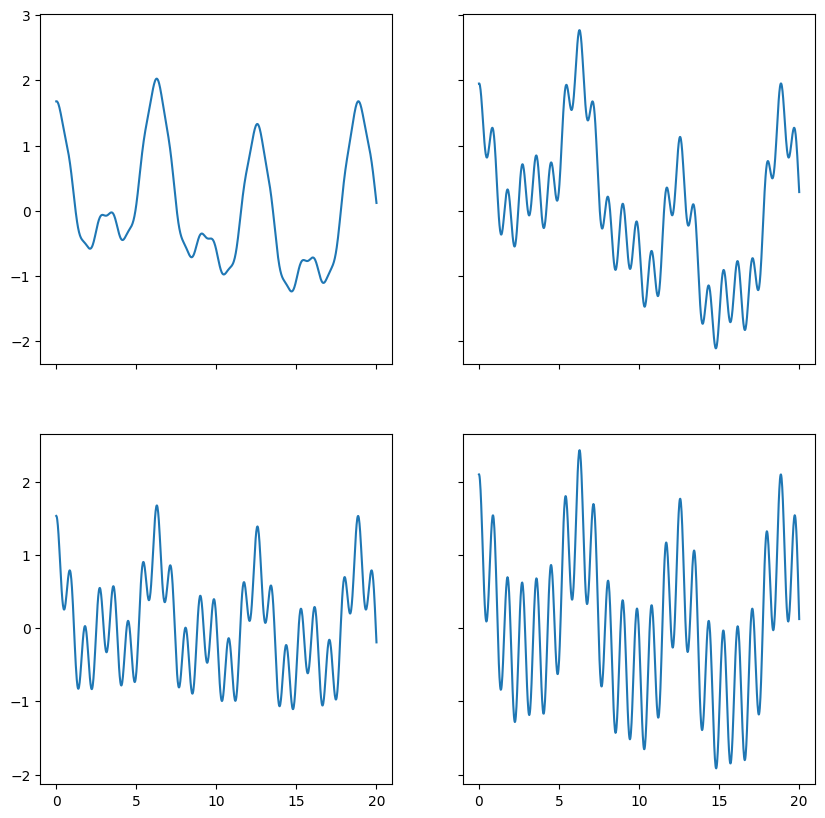

In [39]:
#create mixtures

A = np.random.rand(4,4)

print(A)

z1 = A[0][0]*y1+A[0][1]*y2+A[0][2]*y3+A[0][3]*y4
z2 = A[1][0]*y1+A[1][1]*y2+A[1][2]*y3+A[1][3]*y4
z3 = A[2][0]*y1+A[2][1]*y2+A[2][2]*y3+A[2][3]*y4
z4 = A[3][0]*y1+A[3][1]*y2+A[3][2]*y3+A[3][3]*y4

fig, ax = plt.subplots(2, 2, sharex = "col", sharey = "row", figsize = (10,10))

ax[0,0].plot(x,z1)
ax[1,0].plot(x,z2)
ax[1,1].plot(x,z3)
ax[0,1].plot(x,z4)

plt.show()

In [40]:
X = pd.DataFrame({"z1":z1, "z2":z2, "z3":z3, "z4":z4})

In [41]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components = 4, whiten = "arbitrary-variance")
ica.fit(X)
y_ica = ica.transform(X)

In [42]:
print(ica.mixing_)

[[-13.35443133   1.66006057   9.0468659  -23.05680029]
 [-11.20098784  11.74484739   3.80903916 -11.69451518]
 [ -5.4921061   20.93946168   8.68562538 -20.2088877 ]
 [-11.01558581  10.94412756  20.89346513 -21.90269689]]


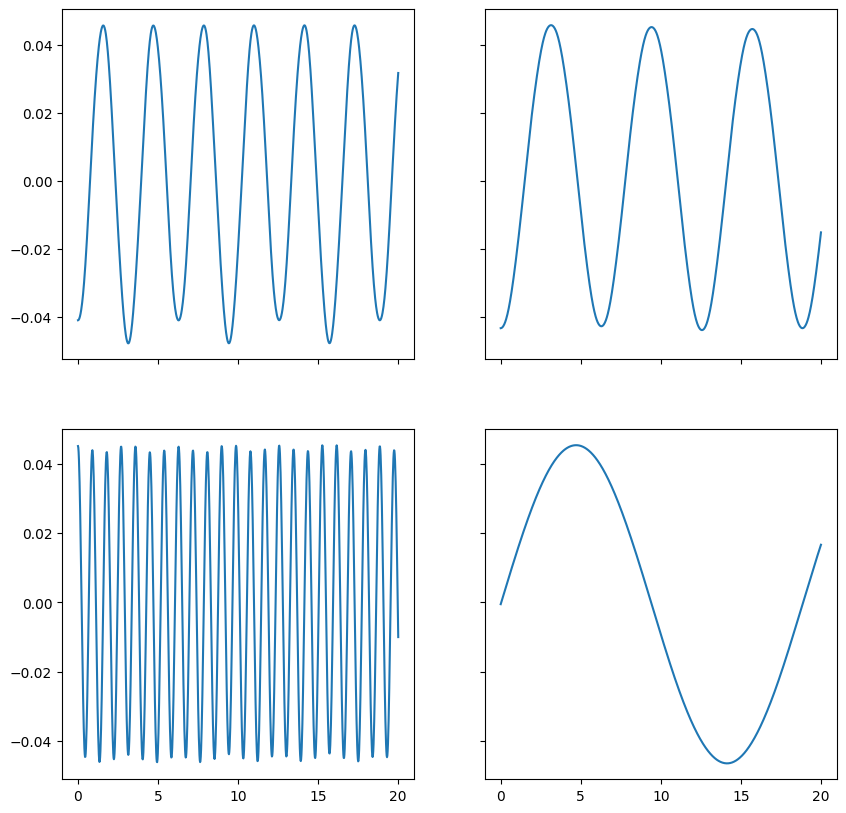

In [43]:
fig, ax = plt.subplots(2, 2, sharex = "col", sharey = "row", figsize = (10,10))

ax[0,0].plot(x,y_ica[:,0])
ax[1,0].plot(x,y_ica[:,1])
ax[1,1].plot(x,y_ica[:,2])
ax[0,1].plot(x,y_ica[:,3])

plt.show()

<h4> Question: Notice that these plots differ in the range of values compared to original signals - is that understandable?

How to use it for dimensionality reduction?

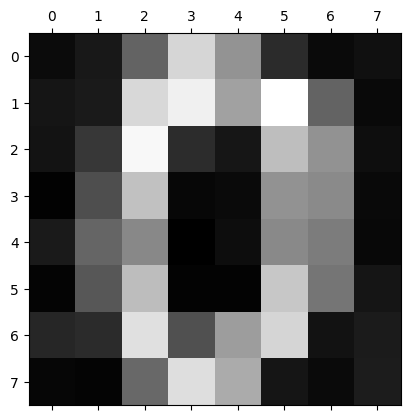

In [29]:
im = digits.data[0].reshape(8,8)+np.random.randn(8, 8)/2
plt.matshow(im, cmap='gray')
plt.show()

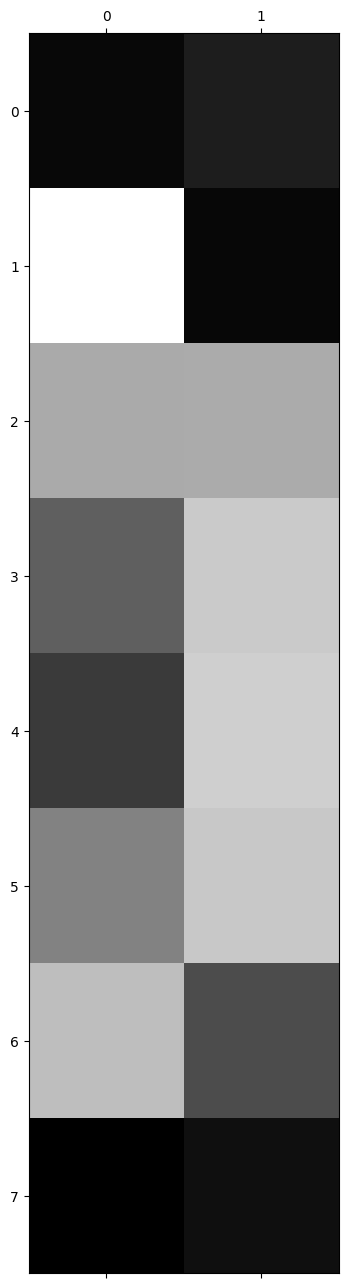

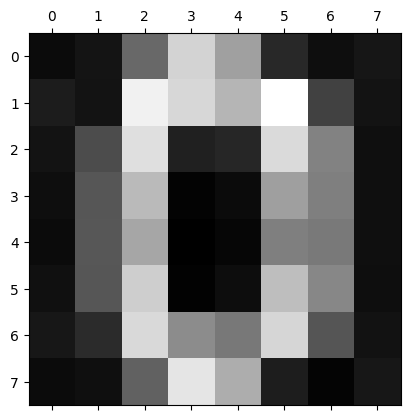

In [30]:
from sklearn.decomposition import FastICA

ica = FastICA(n_components = 2, whiten = "arbitrary-variance")
ica.fit(im)

plt.matshow(ica.fit_transform(im), cmap='gray')

image_restored = ica.inverse_transform(ica.fit_transform(im))

plt.matshow(image_restored, cmap='gray')
plt.show()

Comment: the columns in the picture are a linear combination of these 5 independent vectors


ICA application:
- processing of medical signals (fMRI, ECG, EEG)
- Brain Computer Interface
- time series analysis (e.g. in finance)

and many others

<h4>Exercise 4: Influenza Virus Sequence Analysis</h4>

- Open the file **"influenza viruses"** containing nucleotide sequences of various influenza virus types.

- Represent each sequence as a vector of 4-mer frequencies, resulting in a matrix **X**. What is the number of features?

- Standardize the data.

- Reduce the number of features while preserving 95% of the variance (PCA). How many features remain?

- Apply ICA with 4 components to the PCA-transformed data.

- Use the resulting features to perform hierarchical clustering, and try to group viruses of the same type together. Comment on the results.